### Task 1 — Define Your Prediction Problem

Discuss with your team and choose a research direction. Your prediction must go **beyond a standard weather forecast** — it should answer a question that a regular 7-day forecast does not.

#### Suggested directions

| Direction | Example questions |
|-----------|-------------------|
| **Long-term statistical prediction** | Will May be rainier than the climate norm? Will the majority of July days be above 25 °C? What is the probability that average summer temperature exceeds the 10-year mean? Report results with **confidence intervals** or **probabilities** — think **monthly or seasonal** questions, not next-Tuesday questions. |
| **Spatial refinement** | Take an existing city-scale 7-day forecast and refine it for a **specific location** — a rural area, a particular agricultural field, your neighbourhood — using interpolation, elevation adjustments, or local correction factors. |

Your team may also propose a different direction, as long as it goes beyond what a standard forecast already provides.

In a markdown cell, write:

1. **Problem statement** — One or two sentences describing the question you will answer.
2. **Why it matters** — Who would use this prediction and for what? (e.g., a tea farmer in Lankaran planning irrigation, an energy company forecasting summer demand.)
3. **Prediction target** — What exactly will your model predict? (e.g., "Monthly average temperature for June 2025 in Baku", "Daily precipitation probability for a specific rural coordinate".)
4. **Cities / locations** — List at least 3 cities (coordinates) you plan to use. At least one should be in Azerbaijan.
5. **Weather variables** — List at least 6 daily variables you will fetch (e.g., `temperature_2m_max`, `precipitation_sum`, `windspeed_10m_max`).


#### Problem Statement

We aim to predict next-year crop yield levels (high, medium, low) for multiple agricultural regions using historical weather data and past crop production records from the previous 5–10 years.
Unlike a standard short-term weather forecast, this project focuses on long-term relationships between climate conditions and agricultural productivity, enabling us to estimate how future seasonal weather patterns may influence crop outcomes.

#### Why It Matters

Agricultural production is highly dependent on weather conditions such as temperature, rainfall, and humidity. However, farmers often rely on short-term forecasts, which are not sufficient for long-term planning.

This prediction system can support farmers, policymakers, and agricultural planners in making data-driven decisions, such as:
- selecting the most suitable crops for the upcoming season
- planning irrigation strategies
- preparing for potential risks like drought or excessive rainfall
  
For example, farmers in Lankaran, where citrus production depends on high humidity and rainfall, or in Goychay, known for pomegranate farming, can use these predictions to anticipate whether the next season will be favorable or risky.

#### Prediction Target

The model will predict the crop yield category (High / Medium / Low) for a given:
- region
- crop type
- year
  
To make the prediction more robust and interpretable, continuous yield values will be transformed into categorical levels based on historical distribution (e.g., quantiles).
This approach simplifies the prediction task and allows the model to focus on relative performance rather than exact quantities.

#### Regions

We selected four agricultural regions in Azerbaijan that represent different climate zones and farming conditions:

- Lankaran — 38.7543, 48.8506 (humid subtropical climate, citrus production, tea, rice)
- Jalilabad (Calilabad) — 39.2096, 48.4919 (humid to semi-arid transition, grain production, potatoes, vineyards)
- Guba (Quba) — 41.3611, 48.5134 (temperate mountain climate, apple orchards, fruit production)
- Zagatala — 41.6316, 46.6448 (humid subtropical with mountain influence, hazelnuts, fruits, tobacco)
- Imishli — 39.8700, 48.0600 (semi-arid climate, cotton, grains, livestock farming)
- Sabirabad — 40.0087, 48.4770 (arid to semi-arid climate, cotton, grain crops, melon cultivation)
  
These regions were chosen to ensure diversity in climate and agricultural patterns, improving the model’s ability to generalize.


#### Weather Variables

We will collect daily weather data from the Open-Meteo API and transform it into meaningful yearly and seasonal features that better reflect the impact of climate on agricultural productivity.

The following core weather variables will be used as the foundation:

- temperature_2m_mean — average daily temperature, representing general growing conditions
- temperature_2m_max — maximum daily temperature, capturing potential heat stress
- precipitation_sum — total daily rainfall, indicating water availability
- relative_humidity_2m_mean — average humidity, affecting plant health and disease risk
- windspeed_10m_max — maximum wind speed, influencing evaporation and physical stress on crops
- sunshine_duration —duration of sunlight, directly related to photosynthesis and plant growth

Since crop yield depends on long-term and cumulative environmental conditions rather than daily fluctuations, the raw variables will be transformed into higher-level features through aggregation and statistical processing.

1. Yearly Aggregations

Daily data will be aggregated into yearly indicators such as:

- average temperature
- total precipitation
- total sunshine duration

These features capture the overall climate conditions of each year.

2. Seasonal Indicators

To reflect the biological growth cycle of crops, seasonal features will be created, such as:

- average summer temperature
- total spring precipitation

These indicators allow the model to account for critical growth periods (e.g., spring growth and summer maturation).

3. Extreme Condition Metrics

Extreme weather events often have a stronger impact on yield than average conditions. Therefore, additional features will include:

- number of very hot days (e.g., temperature above a threshold)
- number of dry days (low or zero precipitation)
- number of heavy rainfall days

These variables help capture stress conditions that can significantly affect crop productivity.

4. Variability Measures

Climate stability also plays an important role. Statistical measures such as:

- standard deviation of temperature
- variability in precipitation

will be used to quantify fluctuations in weather conditions.

### Task 2 — Initial Data Inspection

Fetch sample data from both Open-Meteo endpoints and load it into pandas DataFrames.

**No API key is needed.** Open-Meteo is free and open.

1. **Historical data.** For one of your chosen cities, fetch at least 2 full years of daily data from the archive endpoint. Load the JSON response into a DataFrame. Report: shape, column names, data types, date range, and a quick check for missing values.

   ```
   https://archive-api.open-meteo.com/v1/archive?latitude=40.41&longitude=49.87&start_date=2022-01-01&end_date=2024-12-31&daily=temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max
   ```

2. **Forecast data.** For the same city, fetch the current 7-day forecast from the forecast endpoint. Load it into a DataFrame. Report the same summary.

   ```
   https://api.open-meteo.com/v1/forecast?latitude=40.41&longitude=49.87&daily=temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max
   ```

3. **Quick visualisation.** Plot at least one time-series chart from the historical data (e.g., daily max temperature over 2 years) and note any visible gaps, outliers, or seasonal patterns.

4. **Data quality notes.** In a markdown cell, list any issues you noticed (missing rows, suspicious values, gaps) and how they might affect your project.


In [1]:
import requests
import pandas as pd

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 38.7543,
    "longitude": 48.8506,
    "start_date": "2022-01-01",
    "end_date": "2024-12-31",
    "daily": "temperature_2m_mean,temperature_2m_max,precipitation_sum,relative_humidity_2m_mean,windspeed_10m_max,sunshine_duration",
    "timezone": "auto"
}

response = requests.get(url, params=params)
data = response.json()

df_hist = pd.DataFrame(data["daily"])
df_hist["time"] = pd.to_datetime(df_hist["time"])

df_hist

,time,temperature_2m_mean,temperature_2m_max,precipitation_sum,relative_humidity_2m_mean,windspeed_10m_max,sunshine_duration
0,2022-01-01,6.0,11.8,0.0,76,9.0,31934.75
1,2022-01-02,7.9,13.0,0.0,64,10.3,32067.37
2,2022-01-03,7.1,9.7,2.2,77,15.3,22136.69
3,2022-01-04,5.9,10.0,0.0,64,10.2,30407.53
4,2022-01-05,8.5,12.0,0.3,65,9.4,28861.09
...,...,...,...,...,...,...,...
1091,2024-12-27,8.0,9.3,3.5,97,8.7,8255.62
1092,2024-12-28,8.3,9.6,4.7,96,15.7,9078.68
1093,2024-12-29,8.7,12.8,0.0,70,6.6,31970.42
1094,2024-12-30,8.5,9.4,10.3,87,8.4,1239.70


In [2]:
print("Shape:", df_hist.shape)

Shape: (1096, 7)


In [3]:
print("Columns:", df_hist.columns)

Columns: Index(['time', 'temperature_2m_mean', 'temperature_2m_max',
       'precipitation_sum', 'relative_humidity_2m_mean', 'windspeed_10m_max',
       'sunshine_duration'],
      dtype='object')


In [4]:
print("Data types", df_hist.dtypes)

Data types time                         datetime64[ns]
temperature_2m_mean                 float64
temperature_2m_max                  float64
precipitation_sum                   float64
relative_humidity_2m_mean             int64
windspeed_10m_max                   float64
sunshine_duration                   float64
dtype: object


In [5]:
print("Date range:", df_hist["time"].min(), "→", df_hist["time"].max())

Date range: 2022-01-01 00:00:00 → 2024-12-31 00:00:00


In [6]:
print("Missing values:", df_hist.isnull().sum())

Missing values: time                         0
temperature_2m_mean          0
temperature_2m_max           0
precipitation_sum            0
relative_humidity_2m_mean    0
windspeed_10m_max            0
sunshine_duration            0
dtype: int64


In [7]:
url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 38.7543,
    "longitude": 48.8506,
    "daily": "temperature_2m_mean,temperature_2m_max,precipitation_sum,relative_humidity_2m_mean,windspeed_10m_max,sunshine_duration",
    "timezone": "auto"
}

response = requests.get(url, params=params)
data = response.json()

df_forecast = pd.DataFrame(data["daily"])
df_forecast["time"] = pd.to_datetime(df_forecast["time"])

df_forecast

,time,temperature_2m_mean,temperature_2m_max,precipitation_sum,relative_humidity_2m_mean,windspeed_10m_max,sunshine_duration
0,2026-04-19,15.7,20.8,0.3,83,10.5,36000.00
1,2026-04-20,14.9,16.8,0.0,79,19.6,21453.99
2,2026-04-21,12.7,13.4,0.9,87,11.3,0.00
3,2026-04-22,14.0,18.3,0.0,80,18.2,45640.51
4,2026-04-23,15.4,21.5,0.0,82,14.0,47094.19
5,2026-04-24,14.2,17.7,0.0,84,10.5,45516.04
6,2026-04-25,15.6,22.4,0.0,74,7.1,40533.15


In [8]:
print("Shape:", df_forecast.shape)

Shape: (7, 7)


In [9]:
print("Columns:", df_forecast.columns)

Columns: Index(['time', 'temperature_2m_mean', 'temperature_2m_max',
       'precipitation_sum', 'relative_humidity_2m_mean', 'windspeed_10m_max',
       'sunshine_duration'],
      dtype='object')


In [10]:
print("Data types", df_forecast.dtypes)

Data types time                         datetime64[ns]
temperature_2m_mean                 float64
temperature_2m_max                  float64
precipitation_sum                   float64
relative_humidity_2m_mean             int64
windspeed_10m_max                   float64
sunshine_duration                   float64
dtype: object


In [11]:
print("Date range:", df_forecast["time"].min(), "→", df_forecast["time"].max())

Date range: 2026-04-19 00:00:00 → 2026-04-25 00:00:00


In [12]:
print("Missing values:", df_forecast.isnull().sum())

Missing values: time                         0
temperature_2m_mean          0
temperature_2m_max           0
precipitation_sum            0
relative_humidity_2m_mean    0
windspeed_10m_max            0
sunshine_duration            0
dtype: int64


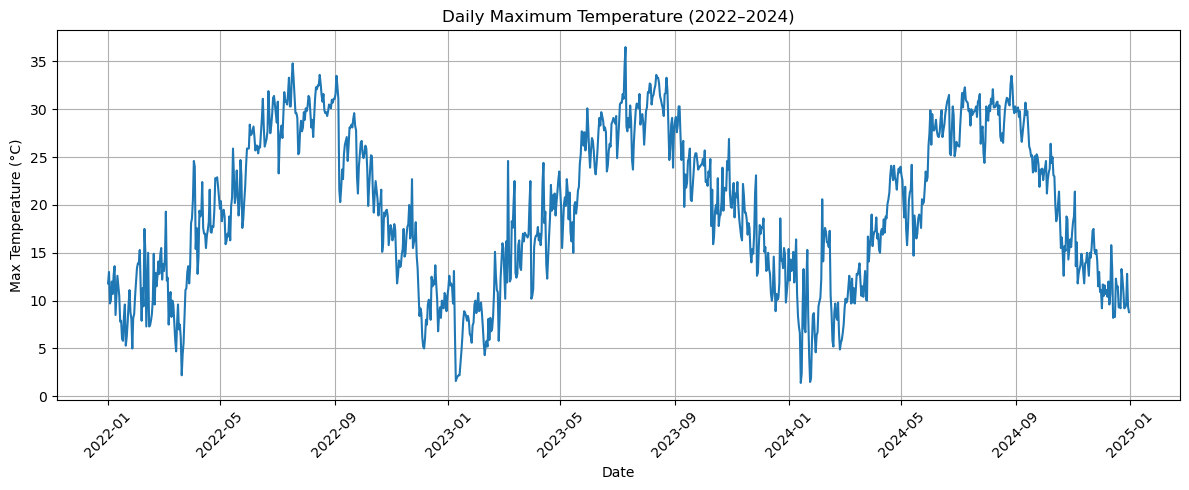

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))  

plt.plot(df_hist["time"], df_hist["temperature_2m_max"])

plt.xlabel("Date")
plt.ylabel("Max Temperature (°C)")
plt.title("Daily Maximum Temperature (2022–2024)")

plt.xticks(rotation=45)
plt.grid()  

plt.tight_layout()
plt.show()

##### Missing Values and Data Continuity
- No missing values were detected in any of the selected features.
- The time series is fully continuous, with no gaps or missing dates visible in the plot.

For example, the temperature line progresses smoothly from early 2022 to the end of 2024 without any breaks or discontinuities.

Impact:
- This ensures that no interpolation or imputation is required, making the dataset reliable for further analysis and modeling.

##### Seasonal Patterns 
A clear and repeating seasonal pattern is visible across all three years.

Temperatures:

- Rise from around 10–15°C in early spring
- Peak at approximately 30–35°C during summer months
- Drop again to around 5–10°C in winter

For example:
- Mid-2022, mid-2023, and mid-2024 all show similar peaks around 30–35°C, indicating consistent summer conditions.
- Early 2023 and early 2024 show noticeable drops to near 5°C or lower, representing winter periods.

Impact:
- This strong seasonality suggests that seasonal or yearly aggregated features (e.g., summer average temperature) will be more meaningful than raw daily values for prediction tasks.

##### Outliers / Extreme Values

- Around mid-2023, temperatures exceed 35°C, indicating possible heatwave conditions.
- Around early 2024, temperatures drop close to 0–5°C, which are unusually low values compared to surrounding days.

Impact:
Extreme temperature values may affect the model by giving too much importance to short-term fluctuations, which can lead to overfitting or misleading patterns. However, they can also capture important stress conditions (e.g., heatwaves or cold spells) that influence crop yield.


### Task 3 — Baseline Model Experiment

Using the historical data from Task 2, build one or two quick models to test whether your prediction idea is feasible. Apply the supervised learning workflow from Unit 4.1.

1. **Create a simple target variable** related to your problem statement. For example:
   - Binary: "Was this day above the monthly climate average?" (classification)
   - Continuous: "Next-day maximum temperature" (regression)
   - Choose whatever makes sense for your direction — this is an experiment, not a final model.

2. **Feature engineering (minimal).** Create at least 2–3 simple features from the raw data (e.g., rolling averages, month indicator, lag features).

3. **Train at least two models.** Use a train/test split (`random_state=42`). Suggested models:
   - `LogisticRegression` or `LinearRegression` (depending on your target)
   - `RandomForestClassifier` or `RandomForestRegressor`

4. **Evaluate.** Report appropriate metrics (accuracy/F1 for classification, RMSE/R² for regression). Create a short comparison table.

5. **Feasibility verdict.** In a markdown cell, answer:
   - Do the results suggest your prediction idea is feasible?
   - What would you need to improve in the full project? (more data, more features, better cleaning, different model?)
   - Any changes to your problem statement based on what you learned?


#### Target variable

To account for seasonal variations, we define a binary target variable indicating whether a given day is warmer than the typical temperature for that month.

Specifically, we compare each day’s maximum temperature to the average maximum temperature of its corresponding month:

- 1 → Above monthly average (warmer than usual)
- 0 → Below or equal to monthly average

This approach allows the model to detect relative temperature anomalies rather than relying on fixed thresholds.

In [14]:
df = df_hist.copy()

df["month"] = df["time"].dt.month 
monthly_avg = df.groupby("month")["temperature_2m_max"].transform("mean")
df["target"] = (df["temperature_2m_max"] > monthly_avg).astype(int)

In [15]:
df["temp_lag1"] = df["temperature_2m_max"].shift(1)
df["temp_roll3"] = df["temperature_2m_max"].rolling(3).mean()
df = df.dropna()

In [16]:
from sklearn.model_selection import train_test_split

X = df[["month", "temp_lag1", "temp_roll3"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   
)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)

print("Logistic Regression Results:")
print("Accuracy:", acc_lr)
print("F1 Score:", f1_lr)

Logistic Regression Results:
Accuracy: 0.5844748858447488
F1 Score: 0.542713567839196


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

print("Random Forest Results:")
print("Accuracy:", acc_rf)
print("F1 Score:", f1_rf)

Random Forest Results:
Accuracy: 0.8356164383561644
F1 Score: 0.8235294117647058


In [19]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [acc_lr, acc_rf],
    "F1 Score": [f1_lr, f1_rf]
})
results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.584475,0.542714
1,Random Forest,0.835616,0.823529


#### Feasibility Verdict
The results suggest that the prediction task is feasible.

The Random Forest model achieves significantly higher performance (Accuracy ≈ 0.84, F1 ≈ 0.82) compared to Logistic Regression (Accuracy ≈ 0.58, F1 ≈ 0.54). This indicates that the model is able to capture meaningful patterns in the data.

The large performance gap between the two models suggests that the relationship between the input features and the target variable is non-linear, which explains why Random Forest performs substantially better than Logistic Regression.

##### What can be improved in the full project?

To improve performance in a full-scale project, several enhancements can be made:

- Use longer historical data (5–10 years) for better generalization
- Include additional weather variables:
   - precipitation
   - humidity
   - sunshine duration
- Create more advanced features:
   - seasonal averages
   - extreme weather indicators
- Improve data preprocessing and alignment
- Experiment with more advanced models (e.g., Gradient Boosting)

##### Changes to the Problem Statement

Based on this experiment, predicting daily temperature anomalies is feasible using weather data.

However, for the main goal of predicting crop yield, the problem should be refined to focus on:

- long-term patterns (seasonal or yearly) instead of daily predictions
- integrating agricultural production data

Thus, the project should shift toward predicting seasonal agricultural outcomes rather than short-term weather variations.